## 1. Data Preprocessing and Target Variable Preparation

In [ ]:
# Cell 1: Import required libraries and load the Excel dataset

import pandas as pd
import numpy as np

# For visualisation later
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# header=2 is used because the actual column names start from the 3rd row in the Excel file
file_path = "Dataset for People for their Blood Glucose Level with their Superficial body feature readings..xlsx"

df = pd.read_excel(file_path, header=2)

# Display first few rows
print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (16969, 10)


,Age,Blood Glucose Level(BGL),Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9,79,73,118,98,98.300707,99,0,0,N
1,9,80,73,119,102,98.300707,94,1,0,N
2,9,70,76,110,81,98.300707,98,1,0,N
3,9,70,78,115,96,98.300707,96,1,0,N
4,66,100,96,144,92,97.807052,98,0,0,N


In [ ]:
# Cell 2: Clean column names for easier coding

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_")
)

# Rename columns clearly
df = df.rename(columns={
    "blood_glucose_levelbgl": "blood_glucose_level",
    "diastolic_blood_pressure": "diastolic_blood_pressure",
    "systolic_blood_pressure": "systolic_blood_pressure",
    "heart_rate": "heart_rate",
    "body_temperature": "body_temperature",
    "spo2": "spo2",
    "sweating__y_n": "sweating_y_n",
    "shivering_y_n": "shivering_y_n",
    "diabetic_nondiabetic_d_n": "diabetic_status"
})

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['age', 'blood_glucose_level', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status']


In [ ]:
# Cell 3: Check dataset structure, missing values, and duplicate records

print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Dataset shape: (16969, 10)

Data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object

Missing values in each column:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64

Number of duplicate rows:
257


In [ ]:
# Cell 4: Remove duplicate rows and handle missing values

# Remove exact duplicate rows
df = df.drop_duplicates()

# Drop rows with missing values
# This is suitable here because the dataset has important medical/sensor readings
df = df.dropna()

print("Shape after removing duplicates and missing values:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after removing duplicates and missing values: (16712, 10)

Remaining missing values:
age                         0
blood_glucose_level         0
diastolic_blood_pressure    0
systolic_blood_pressure     0
heart_rate                  0
body_temperature            0
spo2                        0
sweating_y_n                0
shivering_y_n               0
diabetic_status             0
dtype: int64


In [ ]:
# Cell 5: Convert numerical columns to proper numeric format

numeric_columns = [
    "age",
    "blood_glucose_level",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "heart_rate",
    "body_temperature",
    "spo2"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert sweating and shivering into integer format
df["sweating_y_n"] = df["sweating_y_n"].astype(int)
df["shivering_y_n"] = df["shivering_y_n"].astype(int)

print("Updated data types:")
print(df.dtypes)

Updated data types:
age                           int64
blood_glucose_level           int64
diastolic_blood_pressure      int64
systolic_blood_pressure       int64
heart_rate                    int64
body_temperature            float64
spo2                          int64
sweating_y_n                  int64
shivering_y_n                 int64
diabetic_status              object
dtype: object


In [ ]:
# Cell 6: Create the target column for classification

# Target definition:
# 1 = Hypoglycemia
# 0 = Normal / Not hypoglycemia

df["hypoglycemia_status"] = np.where(df["blood_glucose_level"] < 70, 1, 0)

# Keep target column at the end
target_col = df.pop("hypoglycemia_status")
df["hypoglycemia_status"] = target_col

print("Target column created successfully")
print(df["hypoglycemia_status"].value_counts())

print("\nTarget distribution percentage:")
print(df["hypoglycemia_status"].value_counts(normalize=True) * 100)

Target column created successfully
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64

Target distribution percentage:
hypoglycemia_status
0    69.201771
1    30.798229
Name: proportion, dtype: float64


In [ ]:
# Cell 7: Encode diabetic_status column

# D = Diabetic
# N = Non-diabetic

df["diabetic_status"] = df["diabetic_status"].astype(str).str.strip().str.upper()

df["diabetic_status"] = df["diabetic_status"].map({
    "D": 1,
    "N": 0
})

print("Diabetic status encoded:")
print(df["diabetic_status"].value_counts())

print("\nDataset after encoding:")
display(df.head())

Diabetic status encoded:
diabetic_status
1    16384
0      328
Name: count, dtype: int64

Dataset after encoding:


,age,blood_glucose_level,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,79,73,118,98,98.300707,99,0,0,0,0
1,9,80,73,119,102,98.300707,94,1,0,0,0
2,9,70,76,110,81,98.300707,98,1,0,0,0
3,9,70,78,115,96,98.300707,96,1,0,0,0
4,66,100,96,144,92,97.807052,98,0,0,0,0


In [ ]:
# Cell 8: Prepare final cleaned dataset for machine learning

# IMPORTANT:
# blood_glucose_level is used to create the target.
# Therefore, it should be removed from input features to avoid data leakage.

model_df = df.drop(columns=["blood_glucose_level"])

# Separate input features and target column
X = model_df.drop(columns=["hypoglycemia_status"])
y = model_df["hypoglycemia_status"]

print("Final cleaned dataset shape:", model_df.shape)
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFinal columns used for modelling:")
print(model_df.columns.tolist())

display(model_df.head())

Final cleaned dataset shape: (16712, 10)
Input feature shape: (16712, 9)
Target shape: (16712,)

Final columns used for modelling:
['age', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status', 'hypoglycemia_status']


,age,diastolic_blood_pressure,systolic_blood_pressure,heart_rate,body_temperature,spo2,sweating_y_n,shivering_y_n,diabetic_status,hypoglycemia_status
0,9,73,118,98,98.300707,99,0,0,0,0
1,9,73,119,102,98.300707,94,1,0,0,0
2,9,76,110,81,98.300707,98,1,0,0,0
3,9,78,115,96,98.300707,96,1,0,0,0
4,66,96,144,92,97.807052,98,0,0,0,0


## 2. Exploratory Data Analysis and Feature Relationship Insights

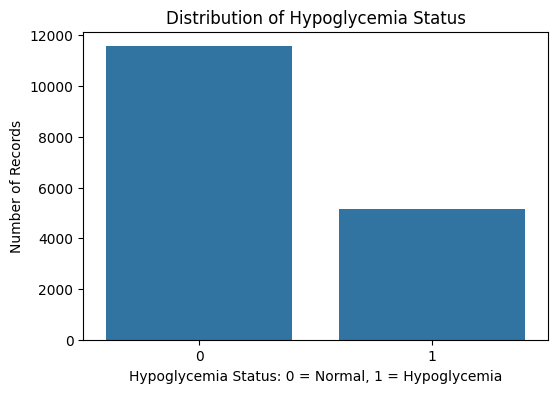

hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64


In [ ]:
# EDA Plot 1: Distribution of hypoglycemia target classes

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="hypoglycemia_status"
)

plt.title("Distribution of Hypoglycemia Status")
plt.xlabel("Hypoglycemia Status: 0 = Normal, 1 = Hypoglycemia")
plt.ylabel("Number of Records")

plt.show()

print(df["hypoglycemia_status"].value_counts())

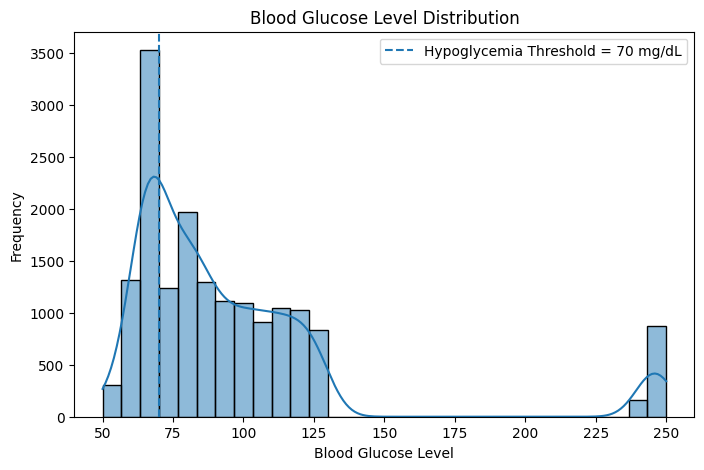

In [ ]:
# EDA Plot 2: Distribution of blood glucose level

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="blood_glucose_level",
    bins=30,
    kde=True
)

# Threshold line for hypoglycemia
plt.axvline(70, linestyle="--", label="Hypoglycemia Threshold = 70 mg/dL")

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.legend()

plt.show()

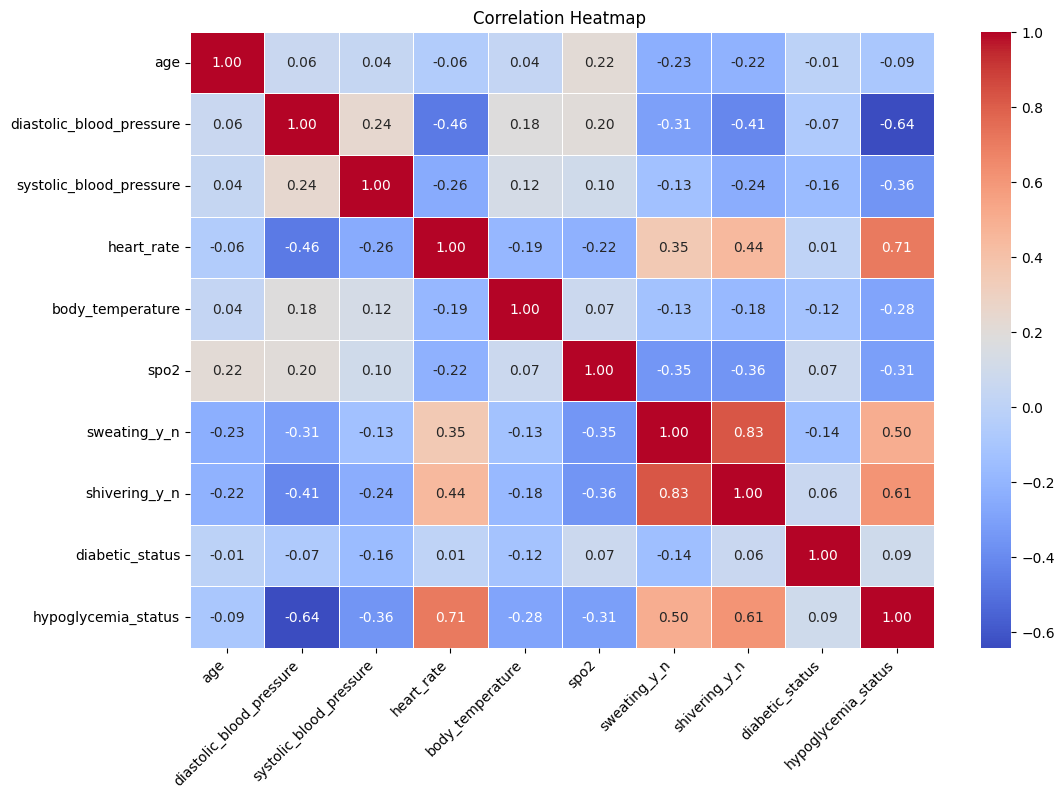

In [ ]:
# EDA Plot 3: Correlation heatmap including hypoglycemia target

# Blood glucose level is removed from this heatmap because it directly defines the target.
# This avoids showing an artificial direct relationship.

heatmap_df = df.drop(columns=["blood_glucose_level"])

corr_matrix = heatmap_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap ")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

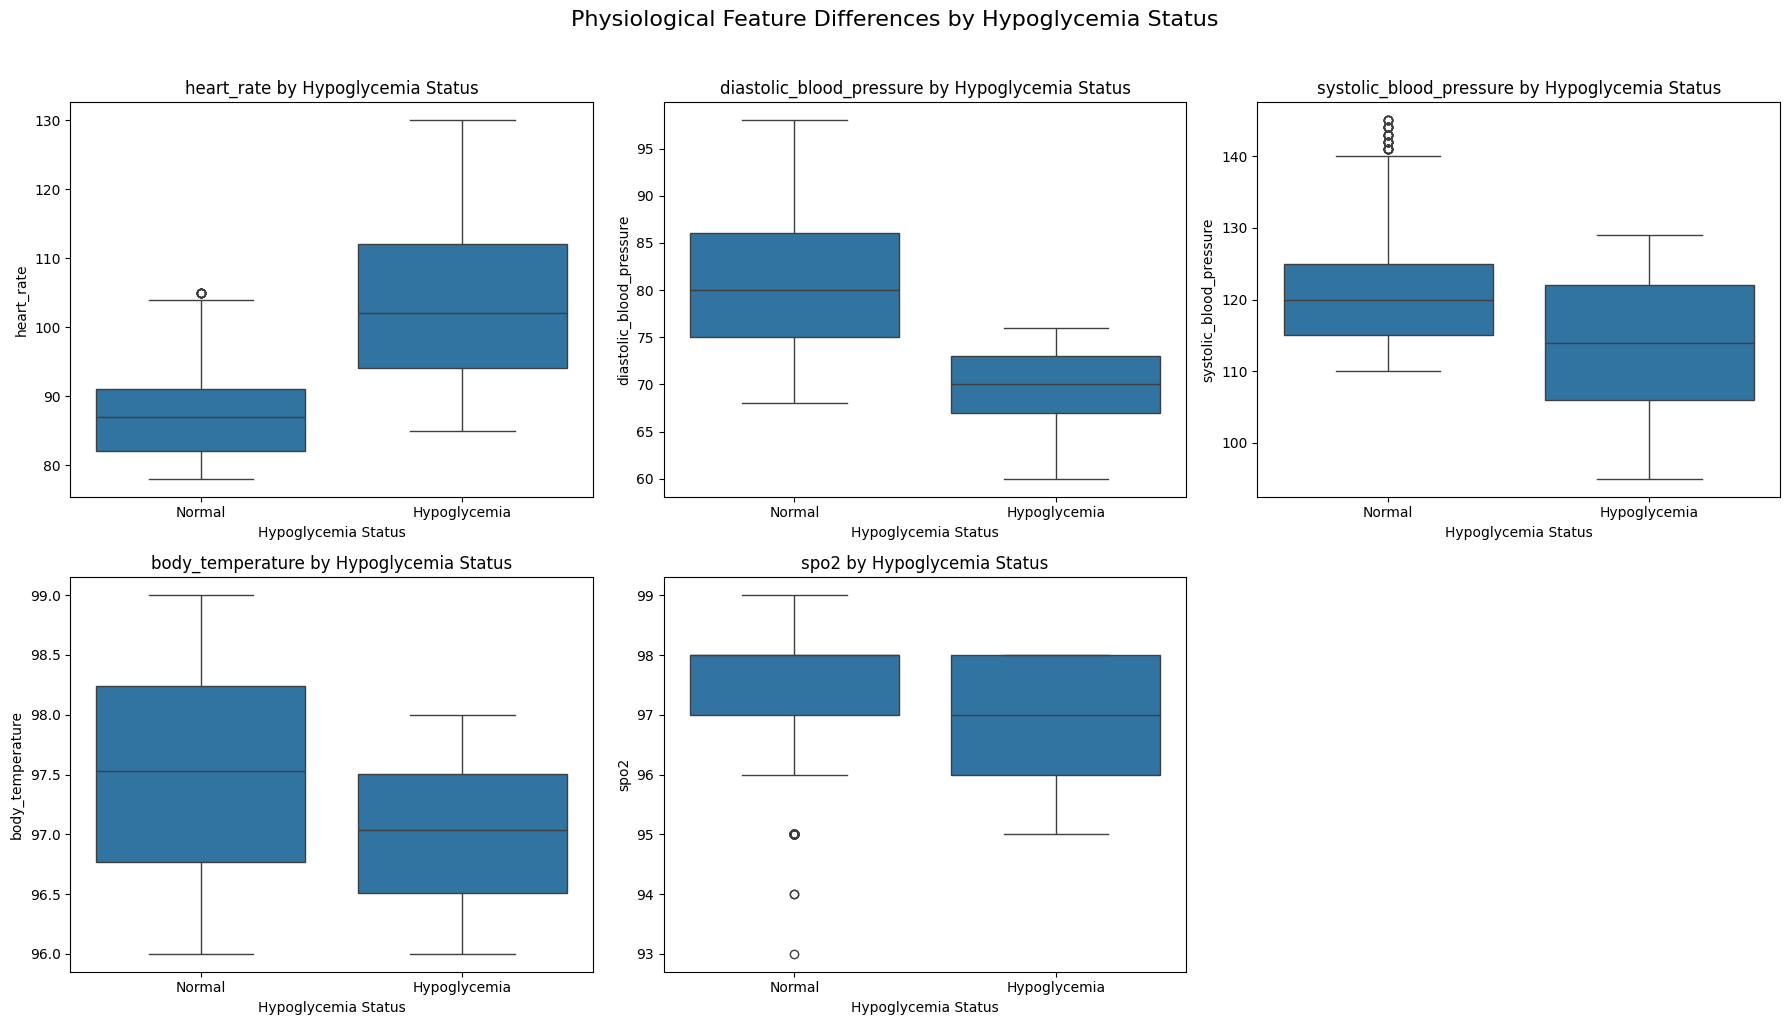

In [ ]:
# EDA Plot 4: Physiological feature differences by hypoglycemia status
# This version creates separate boxplots so that all features are clearly visible.
# It avoids the problem of small-range features like body_temperature and spo2 being compressed.

selected_features = [
    "heart_rate",
    "diastolic_blood_pressure",
    "systolic_blood_pressure",
    "body_temperature",
    "spo2"
]

# Create a copy for plotting
plot_df = df.copy()

# Convert target values into readable labels
plot_df["hypoglycemia_label"] = plot_df["hypoglycemia_status"].map({
    0: "Normal",
    1: "Hypoglycemia"
})

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each physiological feature separately
for i, feature in enumerate(selected_features):
    sns.boxplot(
        data=plot_df,
        x="hypoglycemia_label",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Hypoglycemia Status", fontsize=12)
    axes[i].set_xlabel("Hypoglycemia Status")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=0)

# Remove the empty 6th subplot because only 5 features are used
fig.delaxes(axes[-1])

# Main title
fig.suptitle(
    "Physiological Feature Differences by Hypoglycemia Status",
    fontsize=16,
    y=1.02
)

# Adjust layout so all plots, titles, and labels are visible
plt.tight_layout()

plt.show()

### FEATURE SELECTION AND TARGET SEPARATION

In [ ]:
# =========================================================
# SECTION 4: FEATURE SELECTION AND TARGET SEPARATION
# =========================================================

# Target column
target_column = "hypoglycemia_status"

# Use final cleaned dataset
final_df = model_df.copy()

# Safety check:
# blood_glucose_level should not be used as input feature
# because it was used to create hypoglycemia_status.
if "blood_glucose_level" in final_df.columns:
    final_df = final_df.drop(columns=["blood_glucose_level"])

# Separate input features and target
X = final_df.drop(columns=[target_column])
y = final_df[target_column]

print("Feature and target separation completed")
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features used:")
print(X.columns.tolist())

print("\nOriginal target distribution:")
print(y.value_counts())

Feature and target separation completed
Input feature shape: (16712, 9)
Target shape: (16712,)

Input features used:
['age', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_status']

Original target distribution:
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64


# Applying StandardScaler before SMOTE

In [ ]:
# =========================================================
# SECTION 5: STANDARD SCALING
# =========================================================

from sklearn.preprocessing import StandardScaler

# StandardScaler is used to bring all features to a similar scale.
# This is useful for SMOTE and ANN because both are sensitive to feature distance/scale.

scaler = StandardScaler()

# In this version, scaling is applied before SMOTE and before train-test split,
# as per the new experiment requirement.
X_scaled = scaler.fit_transform(X)

print("StandardScaler applied successfully")
print("Scaled feature shape:", X_scaled.shape)

StandardScaler applied successfully
Scaled feature shape: (16712, 9)


# Apply SMOTE before train-test split

In [ ]:
# =========================================================
# SECTION 6: APPLY SMOTE
# =========================================================

from imblearn.over_sampling import SMOTE

# SMOTE is used to balance the target classes by creating synthetic minority-class records.
# Here SMOTE is applied before train-test split as requested for the new version.

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_scaled, y)

print("SMOTE applied before train-test split")

print("\nTarget distribution before SMOTE:")
print(y.value_counts())

print("\nTarget distribution after SMOTE:")
print(y_smote.value_counts())

print("\nX_smote shape:", X_smote.shape)
print("y_smote shape:", y_smote.shape)

SMOTE applied before train-test split

Target distribution before SMOTE:
hypoglycemia_status
0    11565
1     5147
Name: count, dtype: int64

Target distribution after SMOTE:
hypoglycemia_status
0    11565
1    11565
Name: count, dtype: int64

X_smote shape: (23130, 9)
y_smote shape: (23130,)


In [ ]:
# =========================================================
# SECTION 7: TRAIN-TEST SPLIT AFTER SMOTE
# =========================================================

from sklearn.model_selection import train_test_split

# The balanced SMOTE dataset is now split into training and testing sets.
# stratify=y_smote keeps equal class distribution in train and test data.

X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.20,
    random_state=42,
    stratify=y_smote
)

print("Train-test split completed after SMOTE")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Train-test split completed after SMOTE
X_train shape: (18504, 9)
X_test shape: (4626, 9)
y_train shape: (18504,)
y_test shape: (4626,)

Training target distribution:
hypoglycemia_status
0    9252
1    9252
Name: count, dtype: int64

Testing target distribution:
hypoglycemia_status
1    2313
0    2313
Name: count, dtype: int64


In [ ]:
# =========================================================
# CREATE WITHOUT-SMOTE DATA FOR COMPARISON
# =========================================================

# This cell creates another train-test split without SMOTE.
# Existing X_train, X_test, y_train, y_test are already from SMOTE-before-split version.
# So we keep them as the "With SMOTE" configuration.

# Without SMOTE split using original scaled data
X_train_no_smote, X_test_no_smote, y_train_no_smote, y_test_no_smote = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Without SMOTE data prepared")
print("X_train_no_smote shape:", X_train_no_smote.shape)
print("X_test_no_smote shape:", X_test_no_smote.shape)

print("\nWithout SMOTE training target distribution:")
print(y_train_no_smote.value_counts())

print("\nWithout SMOTE testing target distribution:")
print(y_test_no_smote.value_counts())

print("\nWith SMOTE training target distribution:")
print(y_train.value_counts())

print("\nWith SMOTE testing target distribution:")
print(y_test.value_counts())

Without SMOTE data prepared
X_train_no_smote shape: (13369, 9)
X_test_no_smote shape: (3343, 9)

Without SMOTE training target distribution:
hypoglycemia_status
0    9252
1    4117
Name: count, dtype: int64

Without SMOTE testing target distribution:
hypoglycemia_status
0    2313
1    1030
Name: count, dtype: int64

With SMOTE training target distribution:
hypoglycemia_status
0    9252
1    9252
Name: count, dtype: int64

With SMOTE testing target distribution:
hypoglycemia_status
1    2313
0    2313
Name: count, dtype: int64


# Random Forest base model with metrics, confusion matrix and ROC curve

Random Forest WITHOUT SMOTE
---------------------------
Accuracy : 0.98
Precision: 0.9908
Recall   : 0.9437
F1-score : 0.9667
ROC-AUC  : 0.9972

Classification Report WITHOUT SMOTE:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      2313
Hypoglycemia       0.99      0.94      0.97      1030

    accuracy                           0.98      3343
   macro avg       0.98      0.97      0.98      3343
weighted avg       0.98      0.98      0.98      3343



Random Forest WITH SMOTE
------------------------
Accuracy : 0.9825
Precision: 0.9878
Recall   : 0.9771
F1-score : 0.9824
ROC-AUC  : 0.999

Classification Report WITH SMOTE:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.99      0.98      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98

,Model,Configuration,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,Without SMOTE,0.9800,0.9908,0.9437,0.9667,0.9972
1,Random Forest,With SMOTE,0.9825,0.9878,0.9771,0.9824,0.9990


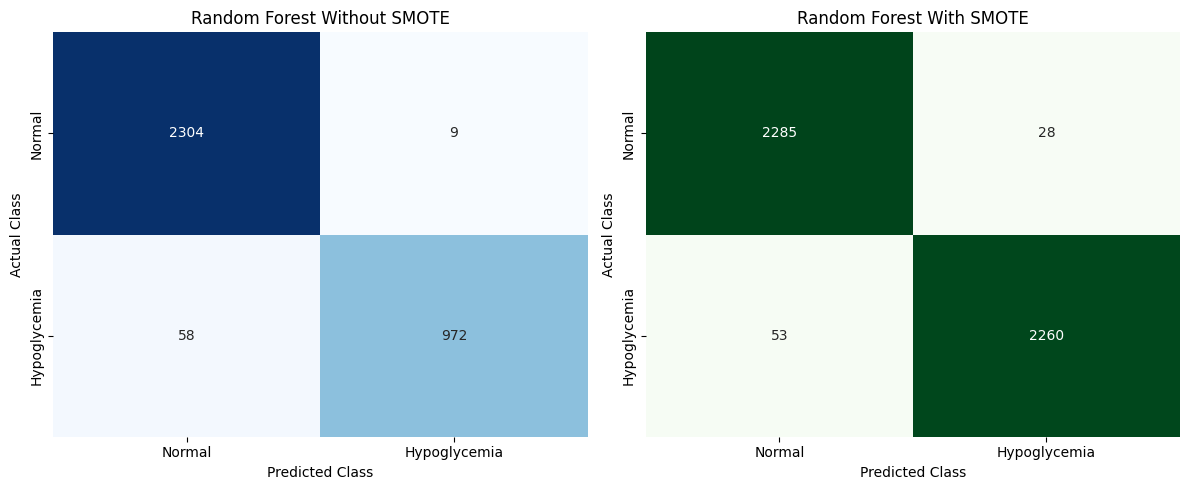

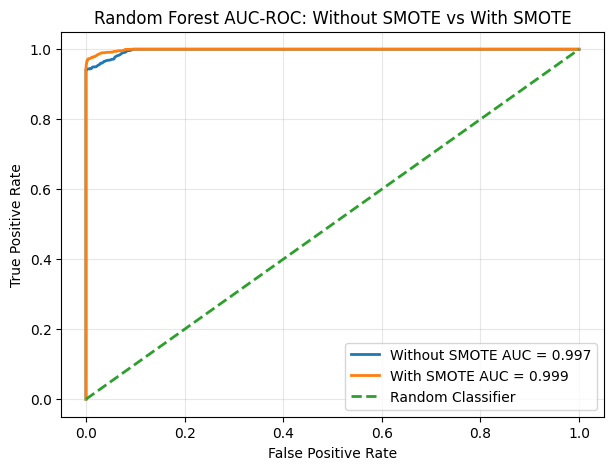

In [ ]:
# =========================================================
# MODEL 1: RANDOM FOREST - BEFORE AND AFTER SMOTE
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# RANDOM FOREST WITHOUT SMOTE
# ---------------------------------------------------------

rf_model_before = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model_before.fit(X_train_no_smote, y_train_no_smote)

rf_pred_before = rf_model_before.predict(X_test_no_smote)
rf_proba_before = rf_model_before.predict_proba(X_test_no_smote)[:, 1]

rf_accuracy_before = accuracy_score(y_test_no_smote, rf_pred_before)
rf_precision_before = precision_score(y_test_no_smote, rf_pred_before)
rf_recall_before = recall_score(y_test_no_smote, rf_pred_before)
rf_f1_before = f1_score(y_test_no_smote, rf_pred_before)
rf_auc_before = roc_auc_score(y_test_no_smote, rf_proba_before)

print("Random Forest WITHOUT SMOTE")
print("---------------------------")
print("Accuracy :", round(rf_accuracy_before, 4))
print("Precision:", round(rf_precision_before, 4))
print("Recall   :", round(rf_recall_before, 4))
print("F1-score :", round(rf_f1_before, 4))
print("ROC-AUC  :", round(rf_auc_before, 4))

print("\nClassification Report WITHOUT SMOTE:")
print(classification_report(
    y_test_no_smote,
    rf_pred_before,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# RANDOM FOREST WITH SMOTE
# ---------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print("\n\nRandom Forest WITH SMOTE")
print("------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report WITH SMOTE:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# RANDOM FOREST COMPARISON TABLE
# ---------------------------------------------------------

rf_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Configuration": ["Without SMOTE", "With SMOTE"],
    "Accuracy": [rf_accuracy_before, rf_accuracy],
    "Precision": [rf_precision_before, rf_precision],
    "Recall": [rf_recall_before, rf_recall],
    "F1-score": [rf_f1_before, rf_f1],
    "ROC-AUC": [rf_auc_before, rf_auc]
}).round(4)

print("\nRandom Forest Comparison")
display(rf_comparison)


# ---------------------------------------------------------
# CONFUSION MATRICES
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_before = confusion_matrix(y_test_no_smote, rf_pred_before)
cm_after = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[0]
)

axes[0].set_title("Random Forest Without SMOTE")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[1]
)

axes[1].set_title("Random Forest With SMOTE")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# AUC-ROC CURVES
# ---------------------------------------------------------

rf_fpr_before, rf_tpr_before, _ = roc_curve(y_test_no_smote, rf_proba_before)
rf_fpr_after, rf_tpr_after, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr_before,
    rf_tpr_before,
    linewidth=2,
    label=f"Without SMOTE AUC = {rf_auc_before:.3f}"
)

plt.plot(
    rf_fpr_after,
    rf_tpr_after,
    linewidth=2,
    label=f"With SMOTE AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Random Forest AUC-ROC: Without SMOTE vs With SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Random Forest hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

Best Random Forest CV ROC-AUC:
0.9988

Tuned Random Forest Results
---------------------------
Accuracy : 0.9825
Precision: 0.9916
Recall   : 0.9732
F1-score : 0.9823
ROC-AUC  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      2313
Hypoglycemia       0.99      0.97      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



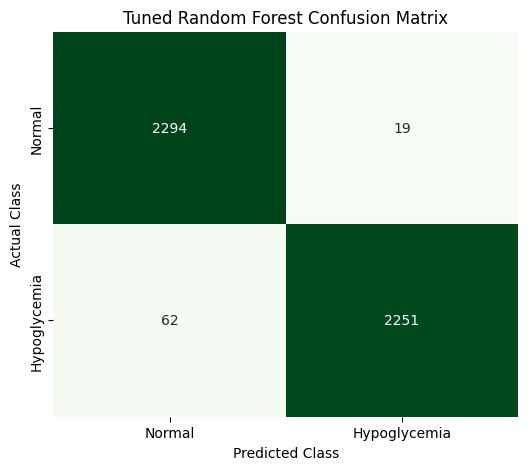

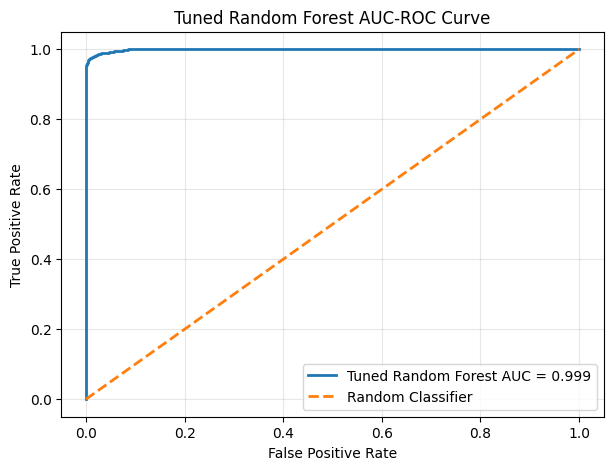

In [ ]:
# =========================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================
from sklearn.model_selection import RandomizedSearchCV

# Base model for tuning
rf_base = RandomForestClassifier(
    random_state=42
)

# Parameter search space
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
rf_random_search.fit(X_train, y_train)

# Best tuned Random Forest model
best_rf_model = rf_random_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(round(rf_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned Random Forest
# ---------------------------------------------------------

rf_tuned_pred = best_rf_model.predict(X_test)
rf_tuned_proba = best_rf_model.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_proba)

print("\nTuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(rf_tuned_accuracy, 4))
print("Precision:", round(rf_tuned_precision, 4))
print("Recall   :", round(rf_tuned_recall, 4))
print("F1-score :", round(rf_tuned_f1, 4))
print("ROC-AUC  :", round(rf_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

rf_tuned_cm = confusion_matrix(y_test, rf_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

rf_tuned_fpr, rf_tuned_tpr, rf_tuned_thresholds = roc_curve(y_test, rf_tuned_proba)
rf_tuned_auc_value = auc(rf_tuned_fpr, rf_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_tuned_fpr,
    rf_tuned_tpr,
    linewidth=2,
    label=f"Tuned Random Forest AUC = {rf_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned Random Forest AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## XGBoost base model with metrics, confusion matrix and ROC curve

XGBoost WITHOUT SMOTE
---------------------
Accuracy : 0.9815
Precision: 1.0
Recall   : 0.9398
F1-score : 0.969
ROC-AUC  : 0.9974

Classification Report WITHOUT SMOTE:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99      2313
Hypoglycemia       1.00      0.94      0.97      1030

    accuracy                           0.98      3343
   macro avg       0.99      0.97      0.98      3343
weighted avg       0.98      0.98      0.98      3343



XGBoost WITH SMOTE
------------------
Accuracy : 0.9784
Precision: 1.0
Recall   : 0.9568
F1-score : 0.9779
ROC-AUC  : 0.9988

Classification Report WITH SMOTE:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      2313
Hypoglycemia       1.00      0.96      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626


XGBoost Compari

,Model,Configuration,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,Without SMOTE,0.9815,1.0,0.9398,0.9690,0.9974
1,XGBoost,With SMOTE,0.9784,1.0,0.9568,0.9779,0.9988


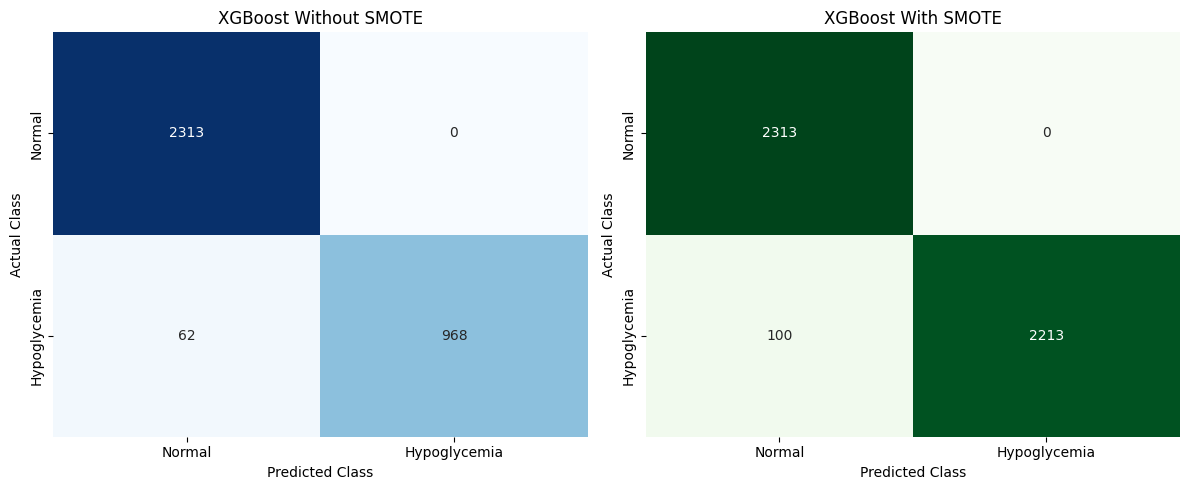

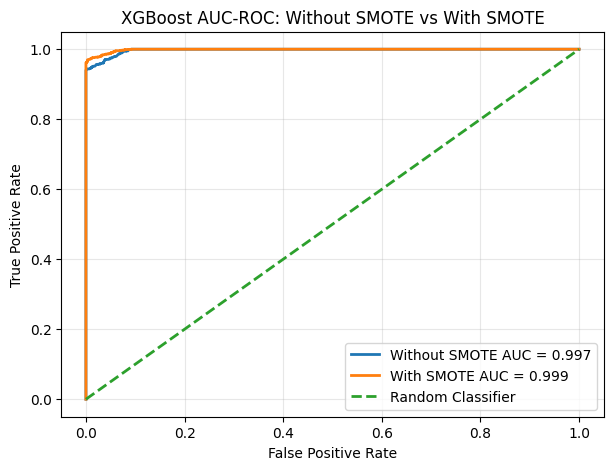

In [ ]:
# =========================================================
# MODEL 2: XGBOOST - BEFORE AND AFTER SMOTE
# =========================================================

from xgboost import XGBClassifier

# ---------------------------------------------------------
# XGBOOST WITHOUT SMOTE
# ---------------------------------------------------------

xgb_model_before = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model_before.fit(X_train_no_smote, y_train_no_smote)

xgb_pred_before = xgb_model_before.predict(X_test_no_smote)
xgb_proba_before = xgb_model_before.predict_proba(X_test_no_smote)[:, 1]

xgb_accuracy_before = accuracy_score(y_test_no_smote, xgb_pred_before)
xgb_precision_before = precision_score(y_test_no_smote, xgb_pred_before)
xgb_recall_before = recall_score(y_test_no_smote, xgb_pred_before)
xgb_f1_before = f1_score(y_test_no_smote, xgb_pred_before)
xgb_auc_before = roc_auc_score(y_test_no_smote, xgb_proba_before)

print("XGBoost WITHOUT SMOTE")
print("---------------------")
print("Accuracy :", round(xgb_accuracy_before, 4))
print("Precision:", round(xgb_precision_before, 4))
print("Recall   :", round(xgb_recall_before, 4))
print("F1-score :", round(xgb_f1_before, 4))
print("ROC-AUC  :", round(xgb_auc_before, 4))

print("\nClassification Report WITHOUT SMOTE:")
print(classification_report(
    y_test_no_smote,
    xgb_pred_before,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# XGBOOST WITH SMOTE
# ---------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("\n\nXGBoost WITH SMOTE")
print("------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

print("\nClassification Report WITH SMOTE:")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# XGBOOST COMPARISON TABLE
# ---------------------------------------------------------

xgb_comparison = pd.DataFrame({
    "Model": ["XGBoost", "XGBoost"],
    "Configuration": ["Without SMOTE", "With SMOTE"],
    "Accuracy": [xgb_accuracy_before, xgb_accuracy],
    "Precision": [xgb_precision_before, xgb_precision],
    "Recall": [xgb_recall_before, xgb_recall],
    "F1-score": [xgb_f1_before, xgb_f1],
    "ROC-AUC": [xgb_auc_before, xgb_auc]
}).round(4)

print("\nXGBoost Comparison")
display(xgb_comparison)


# ---------------------------------------------------------
# CONFUSION MATRICES
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_before = confusion_matrix(y_test_no_smote, xgb_pred_before)
cm_after = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[0]
)

axes[0].set_title("XGBoost Without SMOTE")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[1]
)

axes[1].set_title("XGBoost With SMOTE")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# AUC-ROC CURVES
# ---------------------------------------------------------

xgb_fpr_before, xgb_tpr_before, _ = roc_curve(y_test_no_smote, xgb_proba_before)
xgb_fpr_after, xgb_tpr_after, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_fpr_before,
    xgb_tpr_before,
    linewidth=2,
    label=f"Without SMOTE AUC = {xgb_auc_before:.3f}"
)

plt.plot(
    xgb_fpr_after,
    xgb_tpr_after,
    linewidth=2,
    label=f"With SMOTE AUC = {xgb_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("XGBoost AUC-ROC: Without SMOTE vs With SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# XGBoost hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best XGBoost CV ROC-AUC:
0.9988

Tuned XGBoost Results
---------------------
Accuracy : 0.984
Precision: 0.9899
Recall   : 0.978
F1-score : 0.9839
ROC-AUC  : 0.9989

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.99      0.98      0.98      2313

    accuracy                           0.98      4626
   macro avg       0.98      0.98      0.98      4626
weighted avg       0.98      0.98      0.98      4626



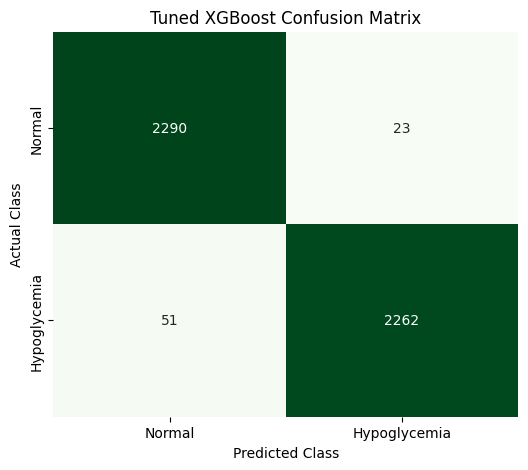

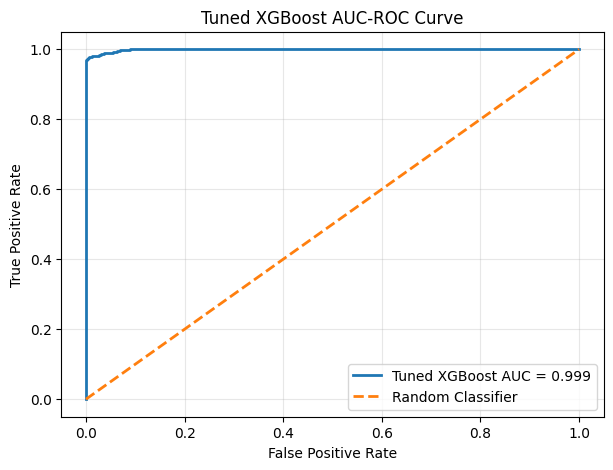

In [ ]:
# =========================================================
# XGBOOST HYPERPARAMETER TUNING
# =========================================================

# Base model for tuning
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameter search space
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2]
}

# RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
xgb_random_search.fit(X_train, y_train)

# Best tuned XGBoost model
best_xgb_model = xgb_random_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nBest XGBoost CV ROC-AUC:")
print(round(xgb_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned XGBoost
# ---------------------------------------------------------

xgb_tuned_pred = best_xgb_model.predict(X_test)
xgb_tuned_proba = best_xgb_model.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)
xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_proba)

print("\nTuned XGBoost Results")
print("---------------------")
print("Accuracy :", round(xgb_tuned_accuracy, 4))
print("Precision:", round(xgb_tuned_precision, 4))
print("Recall   :", round(xgb_tuned_recall, 4))
print("F1-score :", round(xgb_tuned_f1, 4))
print("ROC-AUC  :", round(xgb_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

xgb_tuned_cm = confusion_matrix(y_test, xgb_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

xgb_tuned_fpr, xgb_tuned_tpr, xgb_tuned_thresholds = roc_curve(y_test, xgb_tuned_proba)
xgb_tuned_auc_value = auc(xgb_tuned_fpr, xgb_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_tuned_fpr,
    xgb_tuned_tpr,
    linewidth=2,
    label=f"Tuned XGBoost AUC = {xgb_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned XGBoost AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ANN base model with metrics, confusion matrix and ROC curve

ANN WITHOUT SMOTE
-----------------
Accuracy : 0.9773
Precision: 0.9799
Recall   : 0.9456
F1-score : 0.9625
ROC-AUC  : 0.9971

Classification Report WITHOUT SMOTE:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2313
Hypoglycemia       0.98      0.95      0.96      1030

    accuracy                           0.98      3343
   macro avg       0.98      0.97      0.97      3343
weighted avg       0.98      0.98      0.98      3343



ANN WITH SMOTE
--------------
Accuracy : 0.9725
Precision: 0.9711
Recall   : 0.9741
F1-score : 0.9726
ROC-AUC  : 0.9981

Classification Report WITH SMOTE:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      2313
Hypoglycemia       0.97      0.97      0.97      2313

    accuracy                           0.97      4626
   macro avg       0.97      0.97      0.97      4626
weighted avg       0.97      0.97      0.97      4626


ANN Comparison


,Model,Configuration,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ANN,Without SMOTE,0.9773,0.9799,0.9456,0.9625,0.9971
1,ANN,With SMOTE,0.9725,0.9711,0.9741,0.9726,0.9981


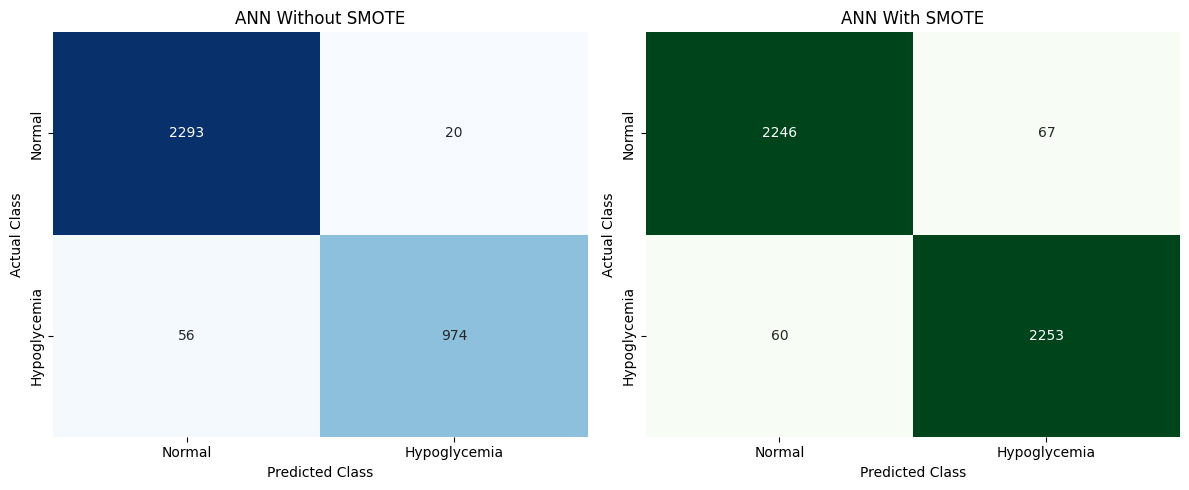

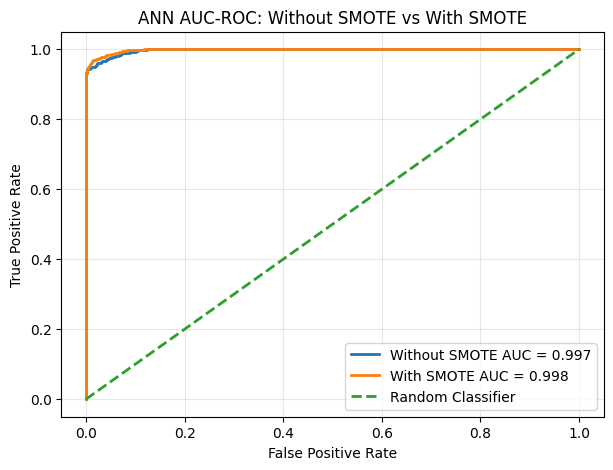

In [ ]:
# =========================================================
# MODEL 3: ANN - BEFORE AND AFTER SMOTE
# =========================================================

from sklearn.neural_network import MLPClassifier

# ---------------------------------------------------------
# ANN WITHOUT SMOTE
# ---------------------------------------------------------

ann_model_before = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

ann_model_before.fit(X_train_no_smote, y_train_no_smote)

ann_pred_before = ann_model_before.predict(X_test_no_smote)
ann_proba_before = ann_model_before.predict_proba(X_test_no_smote)[:, 1]

ann_accuracy_before = accuracy_score(y_test_no_smote, ann_pred_before)
ann_precision_before = precision_score(y_test_no_smote, ann_pred_before)
ann_recall_before = recall_score(y_test_no_smote, ann_pred_before)
ann_f1_before = f1_score(y_test_no_smote, ann_pred_before)
ann_auc_before = roc_auc_score(y_test_no_smote, ann_proba_before)

print("ANN WITHOUT SMOTE")
print("-----------------")
print("Accuracy :", round(ann_accuracy_before, 4))
print("Precision:", round(ann_precision_before, 4))
print("Recall   :", round(ann_recall_before, 4))
print("F1-score :", round(ann_f1_before, 4))
print("ROC-AUC  :", round(ann_auc_before, 4))

print("\nClassification Report WITHOUT SMOTE:")
print(classification_report(
    y_test_no_smote,
    ann_pred_before,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# ANN WITH SMOTE
# ---------------------------------------------------------

ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train, y_train)

ann_pred = ann_model.predict(X_test)
ann_proba = ann_model.predict_proba(X_test)[:, 1]

ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)
ann_auc = roc_auc_score(y_test, ann_proba)

print("\n\nANN WITH SMOTE")
print("--------------")
print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1-score :", round(ann_f1, 4))
print("ROC-AUC  :", round(ann_auc, 4))

print("\nClassification Report WITH SMOTE:")
print(classification_report(
    y_test,
    ann_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# ANN COMPARISON TABLE
# ---------------------------------------------------------

ann_comparison = pd.DataFrame({
    "Model": ["ANN", "ANN"],
    "Configuration": ["Without SMOTE", "With SMOTE"],
    "Accuracy": [ann_accuracy_before, ann_accuracy],
    "Precision": [ann_precision_before, ann_precision],
    "Recall": [ann_recall_before, ann_recall],
    "F1-score": [ann_f1_before, ann_f1],
    "ROC-AUC": [ann_auc_before, ann_auc]
}).round(4)

print("\nANN Comparison")
display(ann_comparison)


# ---------------------------------------------------------
# CONFUSION MATRICES
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_before = confusion_matrix(y_test_no_smote, ann_pred_before)
cm_after = confusion_matrix(y_test, ann_pred)

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[0]
)

axes[0].set_title("ANN Without SMOTE")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"],
    ax=axes[1]
)

axes[1].set_title("ANN With SMOTE")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# AUC-ROC CURVES
# ---------------------------------------------------------

ann_fpr_before, ann_tpr_before, _ = roc_curve(y_test_no_smote, ann_proba_before)
ann_fpr_after, ann_tpr_after, _ = roc_curve(y_test, ann_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    ann_fpr_before,
    ann_tpr_before,
    linewidth=2,
    label=f"Without SMOTE AUC = {ann_auc_before:.3f}"
)

plt.plot(
    ann_fpr_after,
    ann_tpr_after,
    linewidth=2,
    label=f"With SMOTE AUC = {ann_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("ANN AUC-ROC: Without SMOTE vs With SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ANN hyperparameter tuning with metrics, confusion matrix and ROC curve

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best ANN Parameters:
{'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'activation': 'relu'}

Best ANN CV ROC-AUC:
0.9974

Tuned ANN Results
-----------------
Accuracy : 0.9682
Precision: 0.9721
Recall   : 0.9641
F1-score : 0.9681
ROC-AUC  : 0.9974

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97      2313
Hypoglycemia       0.97      0.96      0.97      2313

    accuracy                           0.97      4626
   macro avg       0.97      0.97      0.97      4626
weighted avg       0.97      0.97      0.97      4626



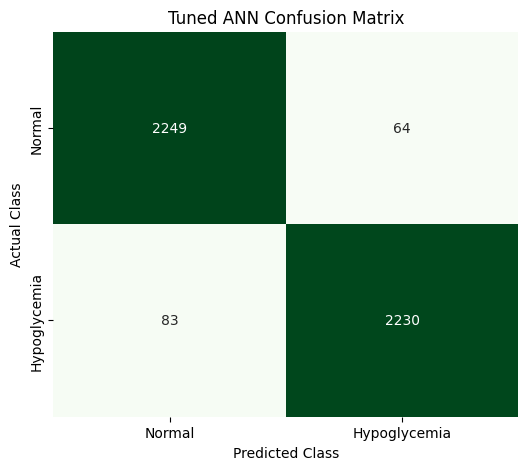

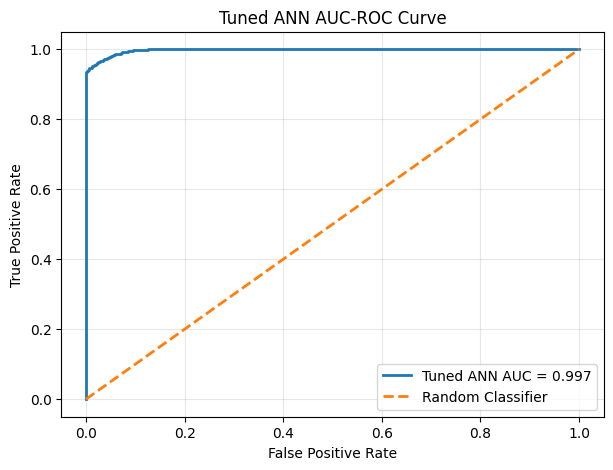

In [ ]:
# =========================================================
# ANN HYPERPARAMETER TUNING
# =========================================================

# Base model for tuning
ann_base = MLPClassifier(
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# Parameter search space
ann_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.005, 0.01]
}

# RandomizedSearchCV
ann_random_search = RandomizedSearchCV(
    estimator=ann_base,
    param_distributions=ann_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train tuning model
ann_random_search.fit(X_train, y_train)

# Best tuned ANN model
best_ann_model = ann_random_search.best_estimator_

print("Best ANN Parameters:")
print(ann_random_search.best_params_)

print("\nBest ANN CV ROC-AUC:")
print(round(ann_random_search.best_score_, 4))


# ---------------------------------------------------------
# Evaluate tuned ANN
# ---------------------------------------------------------

ann_tuned_pred = best_ann_model.predict(X_test)
ann_tuned_proba = best_ann_model.predict_proba(X_test)[:, 1]

ann_tuned_accuracy = accuracy_score(y_test, ann_tuned_pred)
ann_tuned_precision = precision_score(y_test, ann_tuned_pred)
ann_tuned_recall = recall_score(y_test, ann_tuned_pred)
ann_tuned_f1 = f1_score(y_test, ann_tuned_pred)
ann_tuned_auc = roc_auc_score(y_test, ann_tuned_proba)

print("\nTuned ANN Results")
print("-----------------")
print("Accuracy :", round(ann_tuned_accuracy, 4))
print("Precision:", round(ann_tuned_precision, 4))
print("Recall   :", round(ann_tuned_recall, 4))
print("F1-score :", round(ann_tuned_f1, 4))
print("ROC-AUC  :", round(ann_tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    ann_tuned_pred,
    target_names=["Normal", "Hypoglycemia"]
))


# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

ann_tuned_cm = confusion_matrix(y_test, ann_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    ann_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Normal", "Hypoglycemia"],
    yticklabels=["Normal", "Hypoglycemia"]
)

plt.title("Tuned ANN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


# ---------------------------------------------------------
# AUC-ROC Curve
# ---------------------------------------------------------

ann_tuned_fpr, ann_tuned_tpr, ann_tuned_thresholds = roc_curve(y_test, ann_tuned_proba)
ann_tuned_auc_value = auc(ann_tuned_fpr, ann_tuned_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    ann_tuned_fpr,
    ann_tuned_tpr,
    linewidth=2,
    label=f"Tuned ANN AUC = {ann_tuned_auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title("Tuned ANN AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# =========================================================
# FINAL COMPARISON TABLE: ALL MODEL RESULTS
# =========================================================

final_results = pd.DataFrame({
    "Model": [
        "Random Forest Without SMOTE",
        "Random Forest With SMOTE",
        "Tuned Random Forest",
        "XGBoost Without SMOTE",
        "XGBoost With SMOTE",
        "Tuned XGBoost",
        "ANN Without SMOTE",
        "ANN With SMOTE",
        "Tuned ANN"
    ],
    "Accuracy": [
        rf_accuracy_before,
        rf_accuracy,
        rf_tuned_accuracy,
        xgb_accuracy_before,
        xgb_accuracy,
        xgb_tuned_accuracy,
        ann_accuracy_before,
        ann_accuracy,
        ann_tuned_accuracy
    ],
    "Precision": [
        rf_precision_before,
        rf_precision,
        rf_tuned_precision,
        xgb_precision_before,
        xgb_precision,
        xgb_tuned_precision,
        ann_precision_before,
        ann_precision,
        ann_tuned_precision
    ],
    "Recall": [
        rf_recall_before,
        rf_recall,
        rf_tuned_recall,
        xgb_recall_before,
        xgb_recall,
        xgb_tuned_recall,
        ann_recall_before,
        ann_recall,
        ann_tuned_recall
    ],
    "F1-score": [
        rf_f1_before,
        rf_f1,
        rf_tuned_f1,
        xgb_f1_before,
        xgb_f1,
        xgb_tuned_f1,
        ann_f1_before,
        ann_f1,
        ann_tuned_f1
    ],
    "ROC-AUC": [
        rf_auc_before,
        rf_auc,
        rf_tuned_auc,
        xgb_auc_before,
        xgb_auc,
        xgb_tuned_auc,
        ann_auc_before,
        ann_auc,
        ann_tuned_auc
    ]
})

final_results = final_results.round(4)

print("Final Model Results Comparison")
display(final_results)

print("Best Model Based on Accuracy")
display(final_results.sort_values(by="Accuracy", ascending=False).head(1))

print("Best Model Based on Recall")
display(final_results.sort_values(by="Recall", ascending=False).head(1))

print("Best Model Based on ROC-AUC")
display(final_results.sort_values(by="ROC-AUC", ascending=False).head(1))

Final Model Results Comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Without SMOTE,0.9800,0.9908,0.9437,0.9667,0.9972
1,Random Forest With SMOTE,0.9825,0.9878,0.9771,0.9824,0.9990
2,Tuned Random Forest,0.9825,0.9916,0.9732,0.9823,0.9989
3,XGBoost Without SMOTE,0.9815,1.0000,0.9398,0.9690,0.9974
4,XGBoost With SMOTE,0.9784,1.0000,0.9568,0.9779,0.9988
5,Tuned XGBoost,0.9840,0.9899,0.9780,0.9839,0.9989
6,ANN Without SMOTE,0.9773,0.9799,0.9456,0.9625,0.9971
7,ANN With SMOTE,0.9725,0.9711,0.9741,0.9726,0.9981
8,Tuned ANN,0.9682,0.9721,0.9641,0.9681,0.9974


Best Model Based on Accuracy


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
5,Tuned XGBoost,0.984,0.9899,0.978,0.9839,0.9989


Best Model Based on Recall


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
5,Tuned XGBoost,0.984,0.9899,0.978,0.9839,0.9989


Best Model Based on ROC-AUC


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest With SMOTE,0.9825,0.9878,0.9771,0.9824,0.999
